DBSCAN

1. Round 1: unbalanced (sucks)
2. Round 2: undersampled 

In [1]:
import chromadb
from chromadb.config import Settings
import numpy as np
import pandas as pd

CHROMA_DB_PATH = r"G:\.shortcut-targets-by-id\1PSwcGIIcZ7UaovBC2hwABPmME-yIrIoq\ribbit\chromadb"

client = chromadb.PersistentClient(
    path=CHROMA_DB_PATH,
    settings=Settings(anonymized_telemetry=False)
)

collection = client.get_collection(name="anuraset_singlecall")
print(f"✓ Collection loaded: {collection.count()} embeddings")

✓ Collection loaded: 19282 embeddings


In [2]:
results = collection.get(include=['embeddings', 'metadatas'])


In [3]:
results = collection.get(include=['embeddings', 'metadatas'])
embeddings = np.array(results['embeddings'])
metadata_df = pd.DataFrame(results['metadatas'])
metadata_df['date'] = pd.to_datetime(metadata_df['date'])
metadata_df['month'] = metadata_df['date'].dt.month
metadata_df['is_wet_season'] = metadata_df['month'].apply(
    lambda m: 1 if m in [10, 11, 12, 1, 2, 3] else 0
)
metadata_df.drop(columns=['month'], inplace=True)

In [4]:
print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Metadata shape:   {metadata_df.shape}")
metadata_df.head()


Embeddings shape: (19282, 1024)
Metadata shape:   (19282, 7)


,fname,date,min_t,site,species,max_t,is_wet_season
0,INCT20955_20190909_050000,2019-09-09 05:00:00,0.0,INCT20955,SCIPER,3.0,0
1,INCT20955_20190909_050000,2019-09-09 05:00:00,30.0,INCT20955,SCIPER,33.0,0
2,INCT20955_20190909_050000,2019-09-09 05:00:00,37.0,INCT20955,SCIPER,40.0,0
3,INCT20955_20190909_050000,2019-09-09 05:00:00,38.0,INCT20955,SCIPER,41.0,0
4,INCT20955_20190909_050000,2019-09-09 05:00:00,39.0,INCT20955,SCIPER,42.0,0


# DBSCAN 

**Key parameters**
- `eps`: Espsilon Neighborgoud. A radius around a data point. Determined by analysing k-distance graph.
- `MinPts`: minimum number of points required within `eps` radius to form a dense region. Rule of thumb: 

$$MinPts >= D + 1$$

Where D = number of dimensions in dataset. Most cases, MinPts = 3 is recommended. 

**Algorithm**

1. **Identify Core Points**: For each point in the dataset count the number of points within its eps neighborhood. If the count meets or exceeds MinPts mark the point as a core point.
2. **Form Clusters**: For each core point that is not already assigned to a cluster create a new cluster. Recursively find all density-connected points i.e points within the eps radius of the core point and add them to the cluster.
3. **Density Connectivity**: Two points a and b are density-connected if there exists a chain of points where each point is within the eps radius of the next and at least one point in the chain is a core point. This chaining process ensures that all points in a cluster are connected through a series of dense regions.
4. **Label Noise Points**: After processing all points any point that does not belong to a cluster is labeled as noise.

In [55]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.metrics import  silhouette_score, adjusted_rand_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import itertools
import warnings
import tqdm.auto



In [ ]:
singlespecies = pd.read_csv( r"G:\.shortcut-targets-by-id\1PSwcGIIcZ7UaovBC2hwABPmME-yIrIoq\ribbit\chromadb\singlespecies.csv")
season = metadata_df['is_wet_season'].values.reshape(-1, 1) #converts the 'is_wet_season' column to a 2D array with one column, which is required for clustering algorithms
metadata_df['site_code'] = pd.Categorical(metadata_df['site']).codes #converts each site to a unique integer code
site   = metadata_df['site_code'].values.reshape(-1, 1) #converts the 'site_code' column to a 2D array with one column, which is required for clustering algorithms

In [47]:
species_counts = metadata_df['species'].value_counts()
valid_species = species_counts[species_counts >= 100].index

print(f"Species before filter: {metadata_df['species'].nunique()}")
mask = metadata_df['species'].isin(valid_species)
metadata_filtered = metadata_df[mask].reset_index(drop=True)
X_filtered = embeddings[mask]
print(f"Species after filter:  {metadata_filtered['species'].nunique()}")
print(f"Samples after filter:  {len(metadata_filtered)}")

train_idx, test_idx = train_test_split(
    metadata_filtered.index,
    test_size=0.2,
    random_state=42,
    stratify=metadata_filtered['species']
)

X_train = X_filtered[train_idx]
X_test  = X_filtered[test_idx]
meta_train = metadata_filtered.loc[train_idx].reset_index(drop=True)
meta_test  = metadata_filtered.loc[test_idx].reset_index(drop=True)


print(f"\nTrain: {X_train.shape}")
print(f"Test:  {X_test.shape}")

true_labels = pd.Categorical(meta_train['species']).codes


Species before filter: 34
Species after filter:  22
Samples after filter:  18951

Train: (15160, 1024)
Test:  (3791, 1024)


DBSCAN

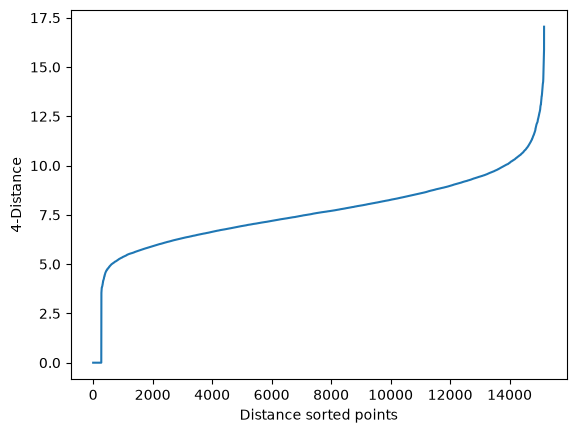

In [48]:
#Taken and adapted from https://stataiml.com/posts/how_to_set_dbscan_paramter/ 
#  Using KNN to determine a good value for eps
# initialize the value of k for kNN which can be same as MinPts (tried 3 and 4, no diff)
k = 4

# Compute k-nearest neighbors
# you need to add 1 to k as this function also return 
# distance to itself (first column is zero)
nbrs = NearestNeighbors(n_neighbors=k+1).fit(X_train)

# get distances
dist, ind = nbrs.kneighbors(X_train)

k_dist = np.sort(dist[:, -1])

plt.plot(k_dist)
plt.xlabel('Distance sorted points')
plt.ylabel(f'{k}-Distance')
plt.show()

Number of clusters: 7
Number of unique labels: 8


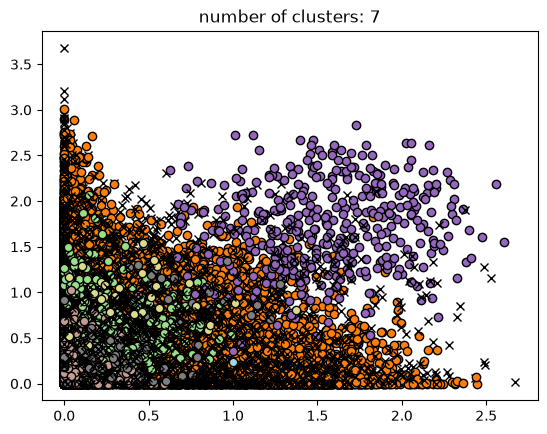

In [51]:
#Taken and adapted fromhttps://www.geeksforgeeks.org/machine-learning/dbscan-clustering-in-ml-density-based-clustering/
db = DBSCAN(eps=12, min_samples=44).fit(X_train)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

unique_labels = sorted(set(labels))
n_clusters_ = len(unique_labels) - (1 if -1 in unique_labels else 0)
print(f"Number of clusters: {n_clusters_}")

cmap = plt.get_cmap('tab20', len(unique_labels))
print(f"Number of unique labels: {len(unique_labels)}")

for i, k in enumerate(unique_labels):
    col = 'k' if k == -1 else cmap(i)

    class_member_mask = (labels == k)

    xy = X_train[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

    xy = X_train[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'x', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()


Evaluation metrics

- Silhouette score is in the range of -1 to 1. A score near 1 denotes the best meaning that the data point i is very compact within the cluster to which it belongs and far away from the other clusters. The worst value is -1. Values near 0 denote overlapping clusters.

- Adjusted Rand Score is in the range of 0 to 1. More than 0.9 denotes excellent cluster recovery and above 0.8 is a good recovery. Less than 0.5 is considered to be poor recovery. 


In [ ]:

sc = metrics.silhouette_score(X_train, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = metrics.adjusted_rand_score(true_labels, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient:0.00
Adjusted Rand Index: 0.08


## Ablation Study: `eps` × `min_samples`

Grid search over `eps` and `min_samples` to find the combination that maximises **Silhouette Coefficient** (higher = tighter, better-separated clusters) and **Adjusted Rand Index** (higher = better agreement with ground-truth species labels).

- Silhouette is computed on a random subsample of non-noise points (max 3 000) to keep wall-time reasonable given 1 024-dim embeddings.  
- ARI is computed on all training points, treating noise points (-1) as their own "cluster".

In [57]:
import itertools
import warnings
from sklearn.metrics import silhouette_score, adjusted_rand_score
from tqdm.auto import tqdm

# --- search grid ---
eps_values        = [5, 7, 10, 12, 15, 20, 25, 30]
min_samples_values = [5, 10, 15, 20, 30, 50]

SILHOUETTE_SUBSAMPLE = 3_000   # cap silhouette computation
RNG = np.random.default_rng(42)

# ground-truth integer labels aligned with X_train
true_labels = pd.Categorical(meta_train['species']).codes

records = []

for eps, min_s in tqdm(list(itertools.product(eps_values, min_samples_values)),
                       desc="DBSCAN grid"):
    db = DBSCAN(eps=eps, min_samples=min_s, n_jobs=-1).fit(X_train)
    pred = db.labels_

    non_noise_mask = pred != -1
    n_clusters     = len(set(pred[non_noise_mask]))
    noise_frac     = (~non_noise_mask).mean()

    # Silhouette — only meaningful when ≥2 clusters and enough non-noise points
    if n_clusters >= 2 and non_noise_mask.sum() >= 2:
        idx = np.where(non_noise_mask)[0]
        if len(idx) > SILHOUETTE_SUBSAMPLE:
            idx = RNG.choice(idx, SILHOUETTE_SUBSAMPLE, replace=False)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sil = silhouette_score(X_train[idx], pred[idx])
    else:
        sil = np.nan

    # ARI — noise points kept as label -1
    ari = adjusted_rand_score(true_labels, pred)

    records.append(dict(eps=eps, min_samples=min_s,
                        n_clusters=n_clusters, noise_frac=noise_frac,
                        silhouette=sil, ari=ari))

results_df = pd.DataFrame(records)
print(results_df.sort_values('silhouette', ascending=False).to_string(index=False))

DBSCAN grid: 100%|██████████| 48/48 [09:57<00:00, 12.45s/it]


 eps  min_samples  n_clusters  noise_frac  silhouette       ari
   5           30           2    0.979683    0.971291  0.000239
   7           50           2    0.976187    0.895376 -0.000285
   5           20           4    0.975726    0.881391  0.000380
   5           15           5    0.974340    0.866957  0.000105
   5           10          14    0.966755    0.779757  0.000364
   5            5          61    0.940172    0.597461  0.000539
   7           30          21    0.915831    0.553732 -0.002901
   7           20          59    0.838720    0.432804  0.002331
   7           15          89    0.788720    0.417788  0.004301
   7           10         167    0.695712    0.362483  0.012064
   7            5         361    0.537203    0.299376  0.018820
  12           50           7    0.128760    0.060124  0.080173
  10           50          12    0.468668    0.042712  0.066015
  10           30          40    0.288654    0.000181  0.089207
  12           30           8    0.07763

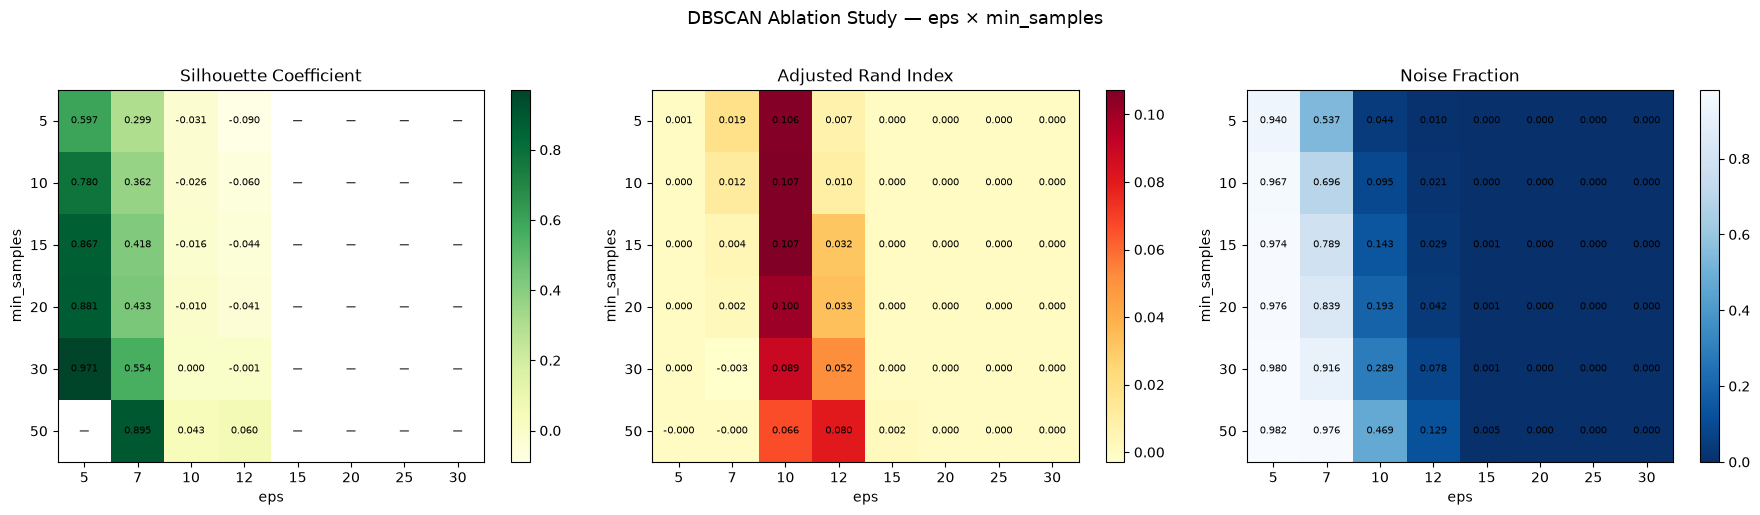

In [58]:
import matplotlib.colors as mcolors

def pivot_metric(df, metric):
    return df.pivot(index='min_samples', columns='eps', values=metric)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_cfg = [
    ('silhouette',  'Silhouette Coefficient', 'YlGn'),
    ('ari',         'Adjusted Rand Index',    'YlOrRd'),
    ('noise_frac',  'Noise Fraction',         'Blues_r'),
]

for ax, (metric, title, cmap) in zip(axes, metrics_cfg):
    mat = pivot_metric(results_df, metric)
    im = ax.imshow(mat.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    ax.set_xlabel('eps')
    ax.set_ylabel('min_samples')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]
            txt = f"{val:.3f}" if not np.isnan(val) else "—"
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='black')

plt.suptitle('DBSCAN Ablation Study — eps × min_samples', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

By looking at the three correlation charts, it would appear that the best eps for noise fraction is 15, but that valule does not deliver great ARI or Silhouette Coefficient, so a trade-off is a slightly lower eps (12). At **`eps`= 12**, the best SC and ARI is at **`min_samples` = 50**. Still, that returns 7 clusters, and many out-of-cluster samples (probably because the previous analysis was with a random sample of 3000)

Number of clusters: 7
Number of unique labels: 8


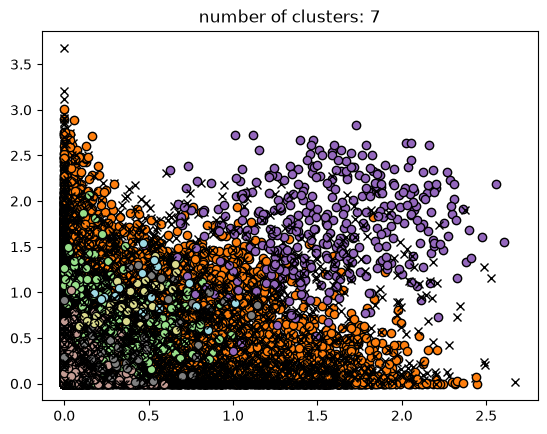

In [60]:
db = DBSCAN(eps=12, min_samples=50).fit(X_train)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

unique_labels = sorted(set(labels))
n_clusters_ = len(unique_labels) - (1 if -1 in unique_labels else 0)
print(f"Number of clusters: {n_clusters_}")

cmap = plt.get_cmap('tab20', len(unique_labels))
print(f"Number of unique labels: {len(unique_labels)}")

for i, k in enumerate(unique_labels):
    col = 'k' if k == -1 else cmap(i)

    class_member_mask = (labels == k)

    xy = X_train[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

    xy = X_train[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'x', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()

In [62]:
# try with whole trainset
from tqdm.auto import tqdm

# --- search grid ---
eps_values        = [5, 7, 10, 12, 15, 20, 25, 30]
min_samples_values = [5, 10, 15, 20, 30, 50]

SILHOUETTE_SUBSAMPLE = len(X_train)   # cap silhouette computation
RNG = np.random.default_rng(42)

# ground-truth integer labels aligned with X_train
true_labels = pd.Categorical(meta_train['species']).codes

records = []

for eps, min_s in tqdm(list(itertools.product(eps_values, min_samples_values)),
                       desc="DBSCAN grid"):
    db = DBSCAN(eps=eps, min_samples=min_s, n_jobs=-1).fit(X_train)
    pred = db.labels_

    non_noise_mask = pred != -1
    n_clusters     = len(set(pred[non_noise_mask]))
    noise_frac     = (~non_noise_mask).mean()

    # Silhouette — only meaningful when ≥2 clusters and enough non-noise points
    if n_clusters >= 2 and non_noise_mask.sum() >= 2:
        idx = np.where(non_noise_mask)[0]
        if len(idx) > SILHOUETTE_SUBSAMPLE:
            idx = RNG.choice(idx, SILHOUETTE_SUBSAMPLE, replace=False)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sil = silhouette_score(X_train[idx], pred[idx])
    else:
        sil = np.nan

    # ARI — noise points kept as label -1
    ari = adjusted_rand_score(true_labels, pred)

    records.append(dict(eps=eps, min_samples=min_s,
                        n_clusters=n_clusters, noise_frac=noise_frac,
                        silhouette=sil, ari=ari))

results_df = pd.DataFrame(records)
print(results_df.sort_values('silhouette', ascending=False).to_string(index=False))

DBSCAN grid: 100%|██████████| 48/48 [15:16<00:00, 19.10s/it]


 eps  min_samples  n_clusters  noise_frac  silhouette       ari
   5           30           2    0.979683    0.971291  0.000239
   7           50           2    0.976187    0.895376 -0.000285
   5           20           4    0.975726    0.881391  0.000380
   5           15           5    0.974340    0.866957  0.000105
   5           10          14    0.966755    0.779757  0.000364
   5            5          61    0.940172    0.597461  0.000539
   7           30          21    0.915831    0.553732 -0.002901
   7           20          59    0.838720    0.432804  0.002331
   7           15          89    0.788720    0.418881  0.004301
   7           10         167    0.695712    0.363934  0.012064
   7            5         361    0.537203    0.305178  0.018820
  12           50           7    0.128760    0.061671  0.080173
  10           50          12    0.468668    0.044388  0.066015
  10           30          40    0.288654    0.001862  0.089207
  12           30           8    0.07763

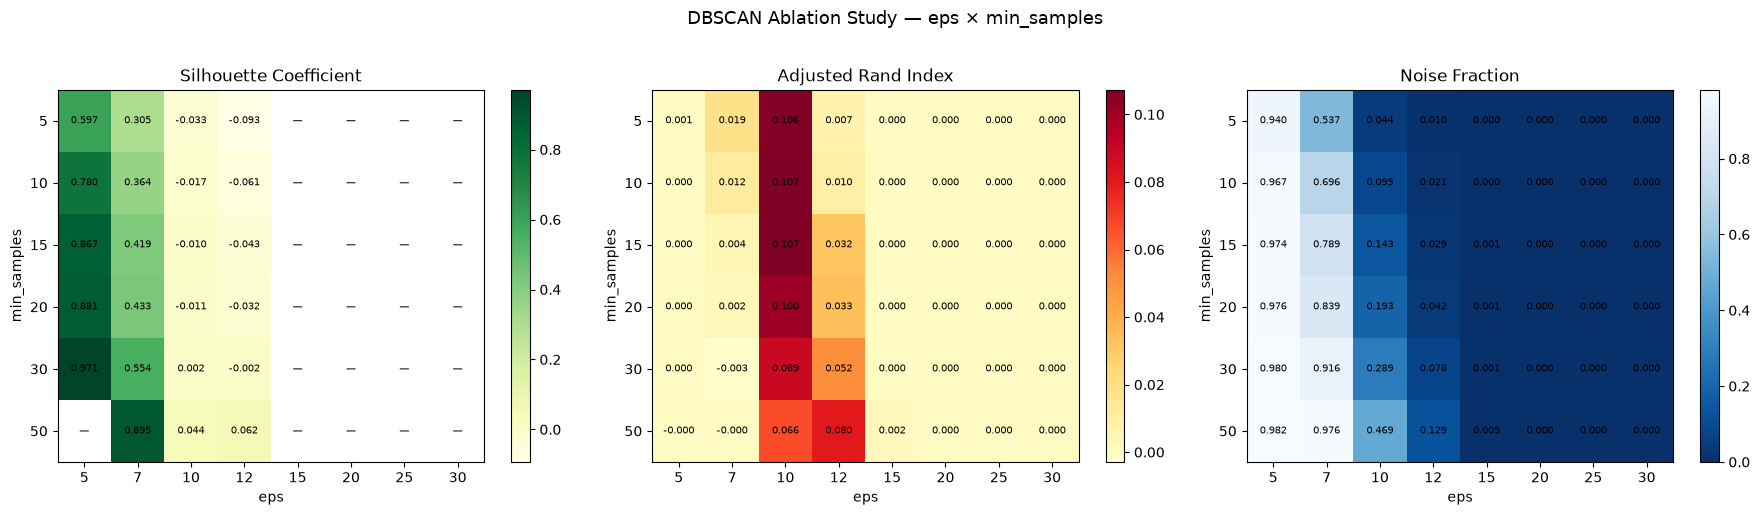

In [63]:
import matplotlib.colors as mcolors

def pivot_metric(df, metric):
    return df.pivot(index='min_samples', columns='eps', values=metric)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_cfg = [
    ('silhouette',  'Silhouette Coefficient', 'YlGn'),
    ('ari',         'Adjusted Rand Index',    'YlOrRd'),
    ('noise_frac',  'Noise Fraction',         'Blues_r'),
]

for ax, (metric, title, cmap) in zip(axes, metrics_cfg):
    mat = pivot_metric(results_df, metric)
    im = ax.imshow(mat.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    ax.set_xlabel('eps')
    ax.set_ylabel('min_samples')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]
            txt = f"{val:.3f}" if not np.isnan(val) else "—"
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='black')

plt.suptitle('DBSCAN Ablation Study — eps × min_samples', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()